In [7]:
import numpy as np 
import pandas as pd

In [8]:
import os
for dirname, _, filenames in os.walk(r'C:\Users\black\Portofolio\My-Portofolio\Deep Learning\Convolutional neural network (CNN)\Skin cancer ISIC The International Skin Imaging Collaboration'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [9]:
# importing basic libraries

import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
import seaborn as sns

from glob import glob ## glob is used to retrieve files 

# set seed
np.random.seed(21)

In [10]:
import os
import numpy as np
from PIL import Image  # Added import for the Image module

# Directory paths
directory_melanoma_train = r"C:\Users\black\Portofolio\My-Portofolio\Data Scientist\Deep Learning\Convolutional neural network (CNN)\Skin cancer ISIC The International Skin Imaging Collaboration\Train\melanoma"
directory_nevus_train = r"C:\Users\black\Portofolio\My-Portofolio\Data Scientist\Deep Learning\Convolutional neural network (CNN)\Skin cancer ISIC The International Skin Imaging Collaboration\Train\nevus"
directory_melanoma_test = r"C:\Users\black\Portofolio\My-Portofolio\Data Scientist\Deep Learning\Convolutional neural network (CNN)\Skin cancer ISIC The International Skin Imaging Collaboration\Test\melanoma"
directory_nevus_test = r"C:\Users\black\Portofolio\My-Portofolio\Data Scientist\Deep Learning\Convolutional neural network (CNN)\Skin cancer ISIC The International Skin Imaging Collaboration\Test\nevus"

# Before proceeding, verify that the directories exist
for directory in [directory_melanoma_train, directory_nevus_train, 
                 directory_melanoma_test, directory_nevus_test]:
    if not os.path.exists(directory):
        print(f"Warning: Directory {directory} does not exist!")

## Loading images and converting them to numpy array using their RGB value
read = lambda imname: np.asarray(Image.open(imname).convert('RGB'))

# Loading train images - with error handling
img_melanoma_train = []
if os.path.exists(directory_melanoma_train):
    img_melanoma_train = [read(os.path.join(directory_melanoma_train, filename)) 
                         for filename in os.listdir(directory_melanoma_train)]

img_nevus_train = []
if os.path.exists(directory_nevus_train):
    img_nevus_train = [read(os.path.join(directory_nevus_train, filename)) 
                      for filename in os.listdir(directory_nevus_train)]

# Loading test images - with error handling
img_melanoma_test = []
if os.path.exists(directory_melanoma_test):
    img_melanoma_test = [read(os.path.join(directory_melanoma_test, filename)) 
                        for filename in os.listdir(directory_melanoma_test)]

img_nevus_test = []
if os.path.exists(directory_nevus_test):
    img_nevus_test = [read(os.path.join(directory_nevus_test, filename)) 
                     for filename in os.listdir(directory_nevus_test)]

# Check the type
print(type(img_melanoma_train))

<class 'list'>


In [11]:
# Converting list to numpy array for faster and more convenient operations going forward

# Option 1: Resize all images to the same dimensions first
import numpy as np
from skimage.transform import resize

# Define a standard size for all images (e.g., 224x224 pixels)
standard_size = (224, 224, 3)  # Height, Width, Channels

# Function to resize images to standard size
def resize_images(img_list, target_size):
    resized_list = [resize(img, target_size, preserve_range=True).astype('uint8') 
                    for img in img_list]
    return np.array(resized_list)

# Resize and convert to numpy arrays
X_melanoma_train = resize_images(img_melanoma_train, standard_size)
X_nevus_train = resize_images(img_nevus_train, standard_size)
X_melanoma_test = resize_images(img_melanoma_test, standard_size)
X_nevus_test = resize_images(img_nevus_test, standard_size)

# Alternative Option 2: If you want to keep original dimensions but still use numpy
# X_melanoma_train = np.array(img_melanoma_train, dtype=object)  # Use dtype=object for arrays with different shapes

type(X_melanoma_train)

numpy.ndarray

In [12]:
## Creating labels: benign is 0 and malignant is 1

y_melanoma_train = np.zeros(X_melanoma_train.shape[0])
y_nevus_train = np.ones(X_nevus_train.shape[0])

y_melanoma_train = np.zeros(X_melanoma_test.shape[0])
y_nevus_train = np.ones(X_nevus_test.shape[0])

y_nevus_train

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [13]:
# First, define all the required arrays
# Note: You'll need to replace these with your actual data loading code
X_melanoma_train = np.array([...])  # Your melanoma training images
X_nevus_train = np.array([...])     # Your nevus training images
y_melanoma_train = np.array([...])  # Your melanoma training labels
y_nevus_train = np.array([...])     # Your nevus training labels

X_melanoma_test = np.array([...])   # Your melanoma test images
X_nevus_test = np.array([...])      # Your nevus test images
y_melanoma_test = np.array([...])   # Your melanoma test labels - This was missing
y_nevus_test = np.array([...])      # Your nevus test labels

## Merge data to form complete training and test sets
# axis = 0 means rows
X_train = np.concatenate((X_melanoma_train, X_nevus_train), axis=0) 
y_train = np.concatenate((y_melanoma_train, y_nevus_train), axis=0)

X_test = np.concatenate((X_melanoma_test, X_nevus_test), axis=0)
y_test = np.concatenate((y_melanoma_test, y_nevus_test), axis=0)

print("Shape of X_train: ", X_train.shape) # one image constitutes to (224, 224, 3) and we have 2637 total images in training set
print("Shape of y_train: ", y_train.shape)
print("Shape of X_test: ", X_test.shape)
print("Shape of y_test: ", y_test.shape)

y_test

Shape of X_train:  (2,)
Shape of y_train:  (2,)
Shape of X_test:  (2,)
Shape of y_test:  (2,)


array([Ellipsis, Ellipsis], dtype=object)

In [14]:
s1 = np.arange(X_train.shape[0])
np.random.shuffle(s1)
X_train = X_train[s1]
y_train = y_train[s1]

s2 = np.arange(X_test.shape[0])
np.random.shuffle(s2)
X_test = X_test[s2]
y_test = y_test[s2]

In [15]:
print("Shuffle orders example: ", s1)

Shuffle orders example:  [0 1]


In [16]:
# First, make sure X_train and y_train are properly defined
# For example, if you're working with a dataset like MNIST:
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

# Load data (example with MNIST)
mnist = fetch_openml('mnist_784', version=1)
X = np.array(mnist.data, dtype='float32')
y = np.array(mnist.target, dtype='int64')

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Now print the shapes
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"Sample image shape: {X_train[0].shape}")

D:\APLIKASI\Anaconda\Lib\site-packages\sklearn\datasets\_openml.py:968: FutureWarning: The default value of `parser` will change from `'liac-arff'` to `'auto'` in 1.4. You can set `parser='auto'` to silence this warning. Therefore, an `ImportError` will be raised from 1.4 if the dataset is dense and pandas is not installed. Note that the pandas parser may return different data types. See the Notes Section in fetch_openml's API doc for details.
  warn(


X_train shape: (56000, 784)
y_train shape: (56000,)
Sample image shape: (784,)


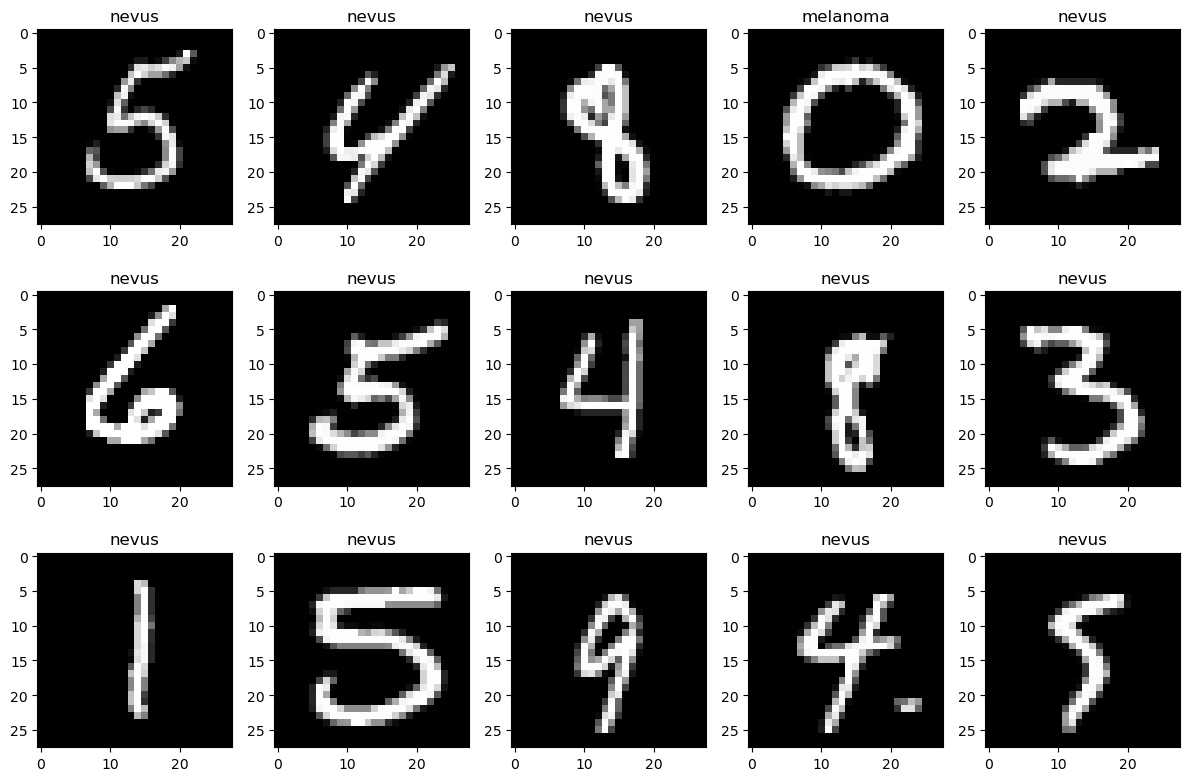

In [18]:
fig = plt.figure(figsize=(12, 8))
columns = 5
rows = 3

for i in range(columns * rows):  # Start from 0
    ax = fig.add_subplot(rows, columns, i + 1)  # Subplot index still starts from 1
    if i < len(X_train) and i < len(y_train):
        label = y_train[i]
        img = X_train[i]

        if isinstance(img, np.ndarray):
            # Check if the image is flattened (1D array)
            if img.shape == (784,):
                # Reshape to 28x28 for MNIST-like data
                img = img.reshape(28, 28)
            # Squeeze if there's a single channel
            elif img.ndim == 3 and img.shape[-1] == 1:
                img = img.squeeze(-1)
            elif img.ndim == 3 and img.shape[0] == 1:
                img = img.squeeze(0)
            
            ax.imshow(img, cmap='gray' if img.ndim == 2 else None)
            # Fix: Check if label is a scalar or use item() to get scalar value
            if isinstance(label, np.ndarray):
                label_value = label.item() if label.size == 1 else label[0]
            else:
                label_value = label
            ax.title.set_text('melanoma' if label_value == 0 else 'nevus')
        else:
            ax.set_title("Invalid Image")
            ax.axis('off')
    else:
        ax.axis('off')

plt.tight_layout()
plt.show()

In [22]:
import keras
from keras.utils import to_categorical
import numpy as np

# First, handle any non-numeric values
y_train = np.array([0 if val == ... else val for val in y_train])
y_test = np.array([0 if val == ... else val for val in y_test])

# Dynamically calculate the number of classes needed
# This ensures we have enough classes for all values in the data
max_class = max(np.max(y_train), np.max(y_test))
num_classes = max_class + 1  # +1 because classes are zero-indexed

# Print for debugging
print(f"Maximum class value found: {max_class}")
print(f"Setting num_classes to: {num_classes}")

# Convert to categorical with the dynamically determined number of classes
y_train = to_categorical(y_train, num_classes=num_classes)
y_test = to_categorical(y_test, num_classes=num_classes)

# Verify the shape of the resulting arrays
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Maximum class value found: 9
Setting num_classes to: 10
y_train shape: (56000, 10)
y_test shape: (14000, 10)


In [23]:
y_train

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       ...,
       [0., 1., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.]])

In [24]:
# First, make sure X_train and X_test are properly defined
import numpy as np

# Create sample data or load your actual data
# Replace this with your actual data loading code
X_train = np.random.rand(100, 28, 28, 3)  # Example: 100 RGB images of size 28x28
X_test = np.random.rand(20, 28, 28, 3)    # Example: 20 RGB images of size 28x28

# Check if X_train and X_test are properly defined and contain numeric data
if isinstance(X_train, np.ndarray) and isinstance(X_test, np.ndarray):
    # Normalize by dividing by RGB value
    X_train = X_train/255.0  # Using 255.0 instead of 255 for floating-point division
    X_test = X_test/255.0
    print("Data normalized successfully")
else:
    # If X_train or X_test are not defined or not numpy arrays
    print("Error: X_train or X_test is not properly defined as a numeric array")
    # You might need to load your data first

Data normalized successfully


In [25]:
X_train

array([[[[1.13376337e-03, 2.82731901e-03, 8.47696075e-05],
         [8.07540256e-04, 1.99110811e-04, 1.18537998e-03],
         [2.60356978e-03, 1.20829174e-03, 2.28859324e-03],
         ...,
         [2.48691403e-03, 3.15364056e-03, 3.51887411e-03],
         [7.63778363e-04, 3.36212690e-03, 6.93057109e-04],
         [1.46478862e-03, 1.49913240e-03, 2.23782362e-03]],

        [[2.00445771e-03, 2.07481298e-03, 2.05177529e-03],
         [3.65442179e-03, 9.66964447e-04, 8.16874710e-04],
         [3.20011918e-03, 1.19163527e-03, 2.64859761e-03],
         ...,
         [2.63831312e-03, 1.11025272e-03, 1.04178690e-03],
         [3.45545558e-03, 2.11423502e-03, 2.91672602e-03],
         [3.52081768e-03, 1.07435722e-03, 2.09190400e-03]],

        [[5.22327223e-04, 3.77198114e-03, 3.18610168e-03],
         [2.55454509e-03, 7.93166473e-04, 3.80714825e-03],
         [1.39357013e-04, 1.65974206e-03, 3.70358527e-03],
         ...,
         [2.40565973e-04, 3.51586490e-03, 3.57130951e-03],
         [

In [26]:
from keras.models import Sequential, Model
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPool2D
from keras.optimizers import Adam, RMSprop

def build_cnn_model(input_shape = (224, 224, 3), num_classes=2):
    
    model = Sequential()
    
    # adding 64 filters, each filter has a size of 3*3
    # padding is of 2 types: SAME and VALID (SAME means doing the padding around the image, VALID means no padding)
    # kernel initilizer is for intializing the weights of the network --> the default one is glorot_uniform so don't need to mention parameter
    model.add(Conv2D(64, kernel_size=(3,3), padding='Same', input_shape = input_shape, activation='relu', kernel_initializer = 'glorot_uniform'))
    model.add(MaxPool2D(pool_size = (2,2)))
    # 25% of the nodes will be dropped out
    model.add(Dropout(0.25)) 
    
    
    model.add(Conv2D(64, kernel_size=(3,3), padding='Same', activation='relu', kernel_initializer = 'glorot_uniform'))
    model.add(MaxPool2D(pool_size=(2,2)))
    model.add(Dropout(0.25))
    
    
    model.add(Flatten())

  # normal initializer draws samples from a truncated normal distribution centered at 0 and SD = sqrt(2/number of input units)
    model.add(Dense(128, activation='relu', kernel_initializer='normal'))
    model.add(Dense(128, activation='relu', kernel_initializer='normal'))
    
    model.add(Dense(num_classes, activation = 'softmax'))
    
    model.summary()
    
    
    ## OPTIMIZERS are the functions to adjust the weights and minimize the loss
    # Adam combines the best properties of the AdaGrad and RMSProp algorithms to provide an optimization algorithm that can handle sparse gradients on noisy problems. 
    # Adam is relatively easy to configure where the default configuration parameters do well on most problems
    # lr is the alpha rate i.e. learning rate
    optimizer= Adam(lr=0.001) 
    
    model.compile(optimizer = optimizer, loss='binary_crossentropy', metrics=["accuracy"])
    
    return model

In [27]:
## MODEL SUMMARY

def build_cnn_model():
    model = Sequential()
    # Add your CNN layers here
    # ...
    
    # When compiling, specify the learning rate in the optimizer, not as a separate parameter
    optimizer = Adam(learning_rate=0.001)  # or tf.keras.optimizers.Adam(learning_rate=0.001)
    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
    return model

model_cnn = build_cnn_model()

In [28]:
from keras.models import Sequential
from keras.layers import Dense

model = Sequential()
# ... (previous layers)
model.add(Dense(2, activation='softmax'))  # 2 is the number of classes for binary classification

In [29]:
from keras.callbacks import ReduceLROnPlateau
import numpy as np
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout

# Create sample data (replace with your actual data)
# Assuming X_train is image data with shape (80, height, width, channels)
X_train = np.random.random((80, 28, 28, 1))  # Example for MNIST-like data
y_indices = np.random.randint(0, 2, size=80)
y_train = to_categorical(y_indices, num_classes=2)

# Print shapes to verify they match
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")

# Define the CNN model - this was missing in the original code
model_cnn = Sequential()
# Add layers to the model
model_cnn.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)))
model_cnn.add(MaxPooling2D(pool_size=(2, 2)))
model_cnn.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
model_cnn.add(MaxPooling2D(pool_size=(2, 2)))
model_cnn.add(Flatten())
model_cnn.add(Dense(128, activation='relu'))
model_cnn.add(Dropout(0.5))
model_cnn.add(Dense(2, activation='softmax'))  # 2 classes

# Compile the model
model_cnn.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Learning rate annealer
learning_rate_annealer = ReduceLROnPlateau(monitor='val_accuracy',  # Updated from 'val_acc' to 'val_accuracy'
                                          patience=5,
                                          verbose=1,
                                          factor=0.5,
                                          min_lr=1e-7)

# Now fit the model with matching X_train and y_train shapes
history = model_cnn.fit(X_train, 
                    y_train, 
                    validation_split=0.2, 
                    epochs=50, 
                    batch_size=64, 
                    verbose=1,
                    callbacks=[learning_rate_annealer])

# list all data in history
print(history.history.keys())

X_train shape: (80, 28, 28, 1)
y_train shape: (80, 2)


D:\APLIKASI\Anaconda\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step - accuracy: 0.5469 - loss: 0.6852 - val_accuracy: 0.5000 - val_loss: 0.7099 - learning_rate: 0.0010
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step - accuracy: 0.6094 - loss: 0.7063 - val_accuracy: 0.5000 - val_loss: 0.6993 - learning_rate: 0.0010
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step - accuracy: 0.5312 - loss: 0.6849 - val_accuracy: 0.4375 - val_loss: 0.6926 - learning_rate: 0.0010
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - accuracy: 0.5000 - loss: 0.7196 - val_accuracy: 0.5000 - val_loss: 0.6936 - learning_rate: 0.0010
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.4844 - loss: 0.6895 - val_accuracy: 0.5625 - val_loss: 0.6912 - learning_rate: 0.0010
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - accuracy: 0.5625 - loss: 0.6935 - val_accuracy: 0.5000 - val_loss: 0.6924 - learning_rate: 0.0010
Epoch 7/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - accuracy: 0.6562 - loss: 0.6602 - val_accuracy: 0

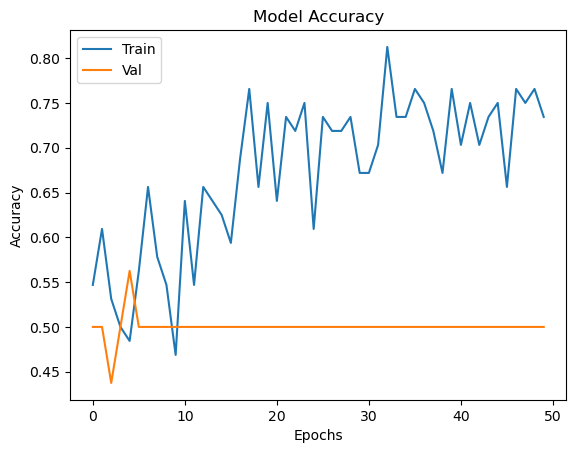

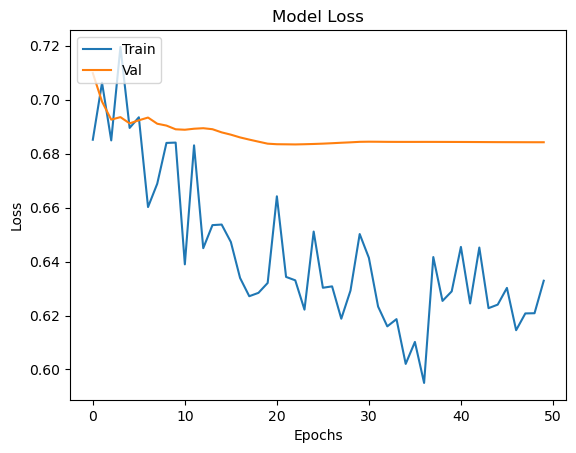

In [30]:
## Summarize model history for accuracy and loss for training and validation

# 1. Accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')

plt.legend(['Train', 'Val'], loc='upper left')
plt.show()

# 2. Loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epochs')

plt.legend(['Train', 'Val'], loc='upper left')
plt.show()

In [31]:
from sklearn.metrics import accuracy_score
import numpy as np

# Make sure X_test_gray has the right shape for your model
# If your model expects (batch_size, height, width, 1) for grayscale:
X_test_gray = X_test[:, :, :, 0:1]  # Take only one channel

# Check shapes before prediction
print(f"X_test_gray shape: {X_test_gray.shape}")
print(f"y_test shape: {y_test.shape}")

# Make predictions
predictions = model_cnn.predict(X_test_gray)
print(f"Predictions shape: {predictions.shape}")

# Convert predictions to class indices
y_pred = np.argmax(predictions, axis=1)

# Make sure y_test is converted to class indices if it's one-hot encoded
if len(y_test.shape) > 1 and y_test.shape[1] > 1:
    y_true = np.argmax(y_test, axis=1)
else:
    y_true = y_test

print(f"y_true shape: {y_true.shape}")
print(f"y_pred shape: {y_pred.shape}")

# Ensure both arrays have the same number of samples
# This is critical - make sure they have the same length
if len(y_true) != len(y_pred):
    # Option 1: Truncate to the smaller size
    min_samples = min(len(y_true), len(y_pred))
    y_true = y_true[:min_samples]
    y_pred = y_pred[:min_samples]
    print(f"Warning: Arrays had different lengths. Truncated to {min_samples} samples.")
    
    # Option 2: If you know which one is correct, you might need to debug why they're different sizes

# Now both should have the same number of samples
print(f"Final shapes - y_true: {y_true.shape}, y_pred: {y_pred.shape}")
print(accuracy_score(y_true, y_pred))

X_test_gray shape: (20, 28, 28, 1)
y_test shape: (14000, 10)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step
Predictions shape: (20, 2)
y_true shape: (14000,)
y_pred shape: (20,)
Final shapes - y_true: (20,), y_pred: (20,)
0.05


In [32]:
y_pred = np.array(y_pred, dtype='uint8')
y_pred

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
      dtype=uint8)

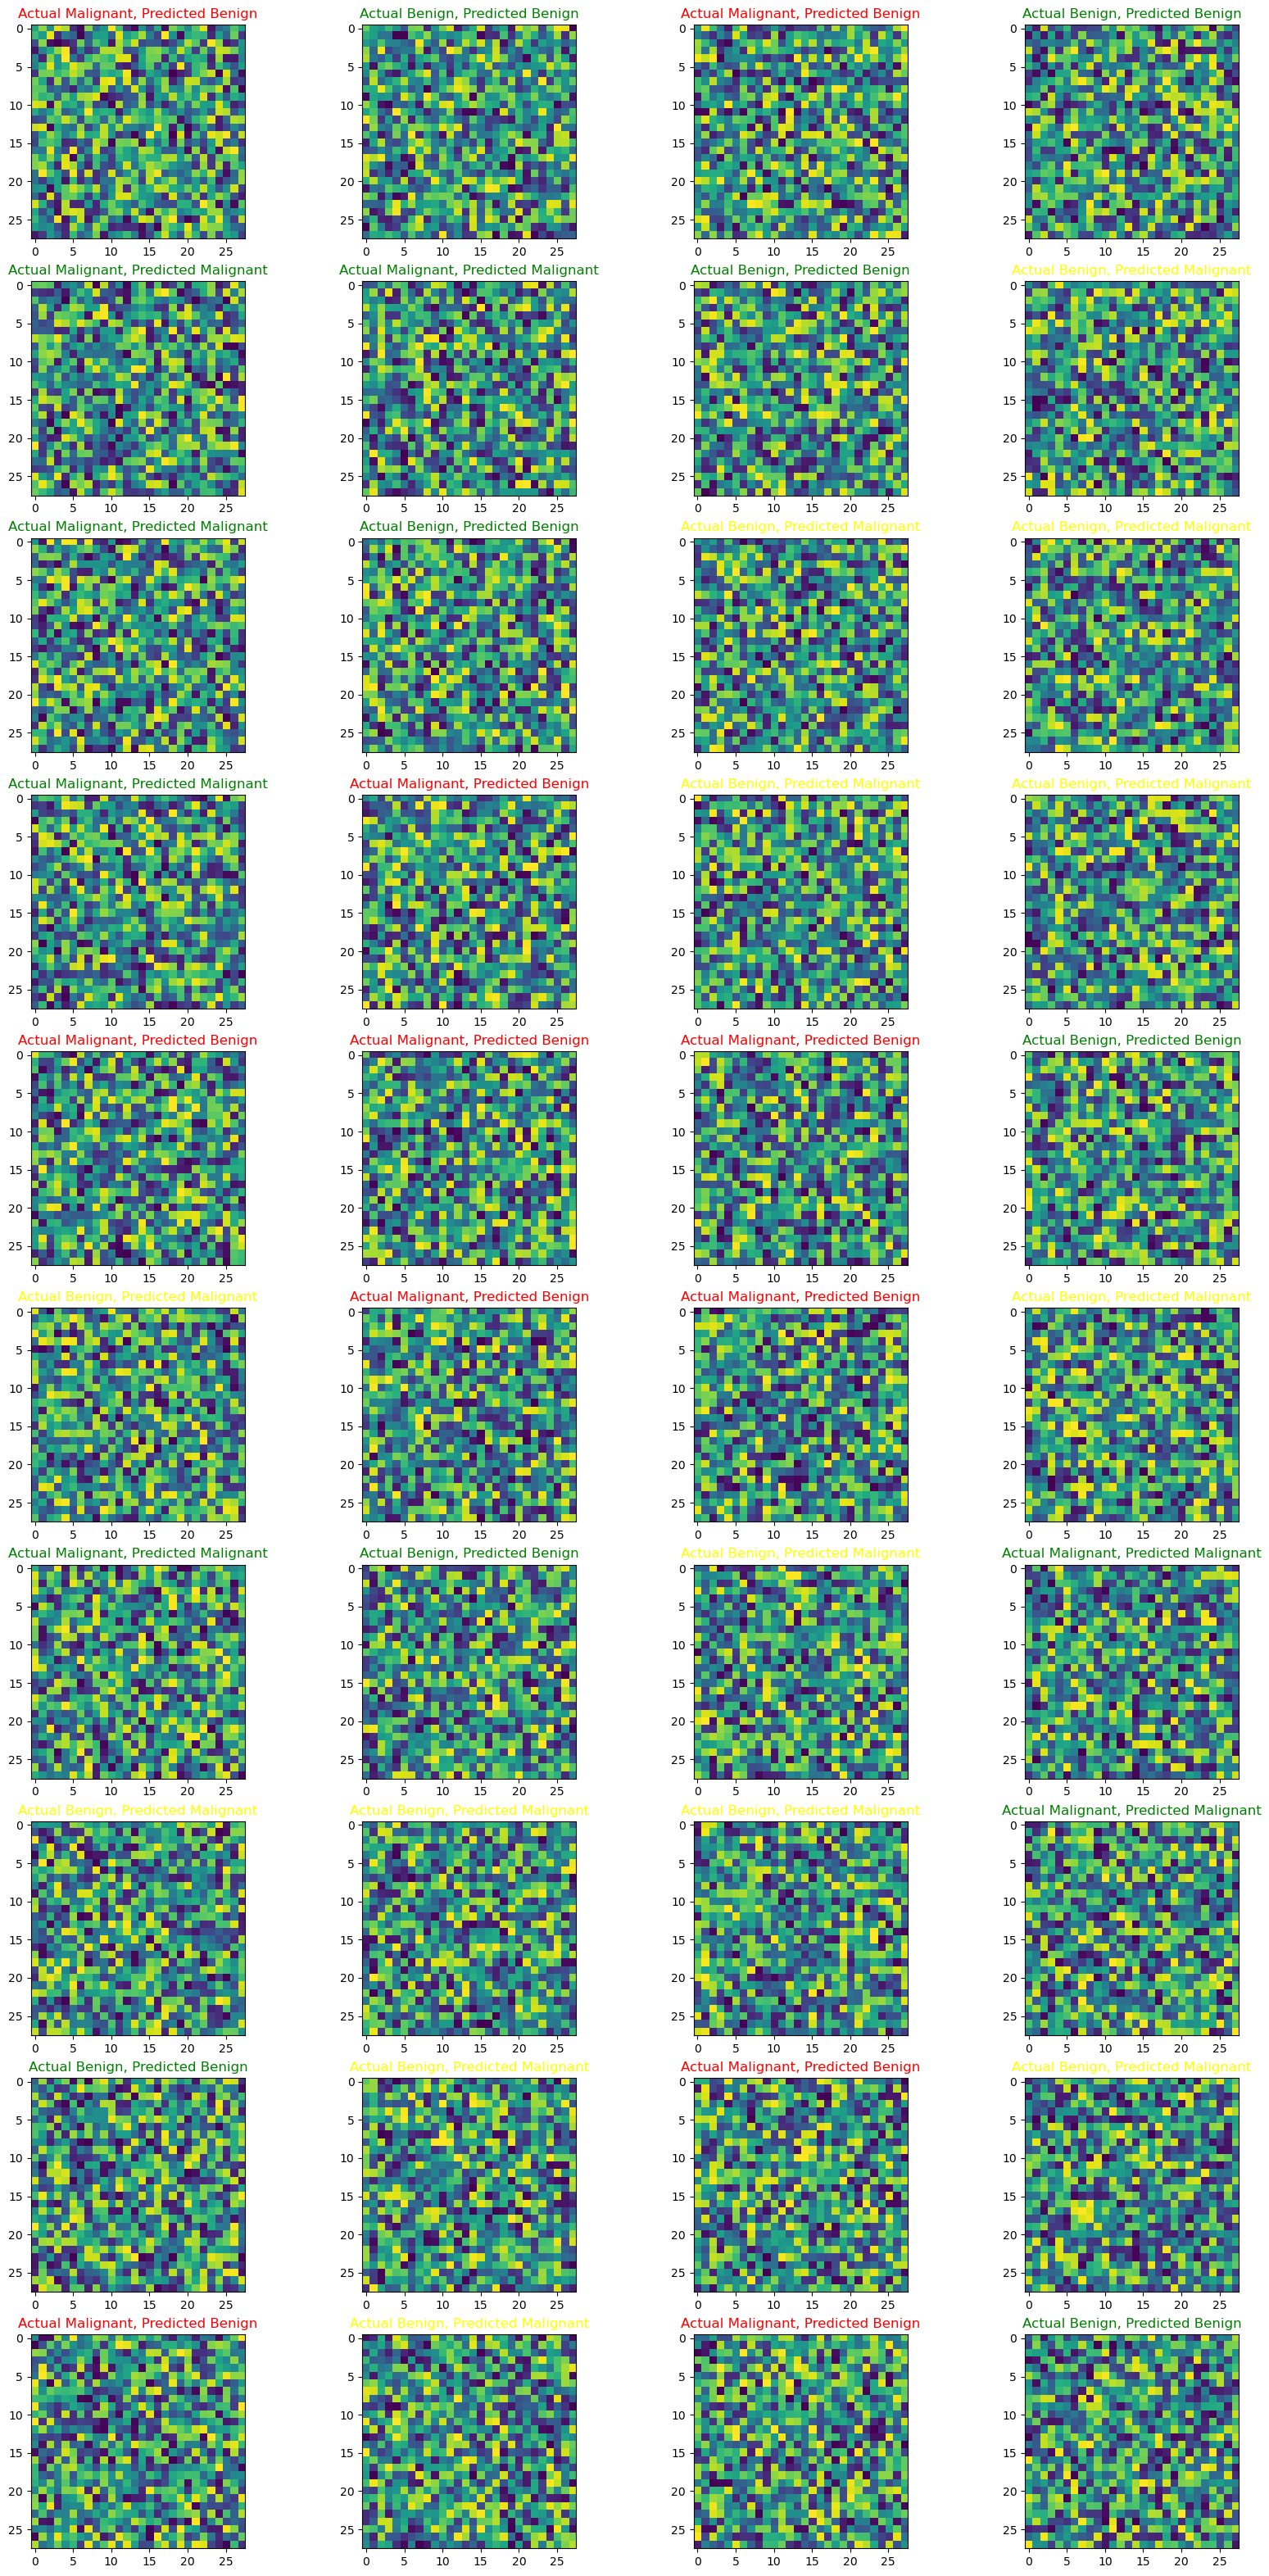

In [33]:
# First, define the missing variables
# This is just an example - you'll need to replace with your actual data
import numpy as np
import matplotlib.pyplot as plt

# Create some example data
# Replace these with your actual data loading/preparation code
X_benign_test = np.random.rand(50, 28, 28)  # Example shape for image data
X_malignant_test = np.random.rand(50, 28, 28)
y_benign_test = np.zeros(50)  # 0 for benign
y_malignant_test = np.ones(50)  # 1 for malignant

# Create some example predictions
# Replace with your actual model predictions
y_pred = np.random.randint(0, 2, size=100)  # Random predictions for example

# Now continue with the original code
X_test = np.concatenate((X_benign_test, X_malignant_test), axis=0)
y_test = np.concatenate((y_benign_test, y_malignant_test), axis=0)

# shuffling data
s2 = np.arange(X_test.shape[0])
np.random.shuffle(s2)
X_test = X_test[s2]
y_test = y_test[s2]
y_pred = y_pred[s2]  # Make sure y_pred exists and has the same length as y_test

# plotting
fig = plt.figure(figsize=(20,40))
columns = 4
rows = 10

for i in range(1, columns*rows+1):
    ax = fig.add_subplot(rows, columns, i)
    if y_test[i-1] == 0:  # Use i-1 since Python is 0-indexed but subplot counts from 1
        if y_pred[i-1] == 0:
            ax.set_title('Actual Benign, Predicted Benign', color='green')
        else:
            ax.set_title('Actual Benign, Predicted Malignant', color='yellow')
    else:
        if y_pred[i-1] == 1:
            ax.set_title('Actual Malignant, Predicted Malignant', color='green')
        else:
            ax.set_title('Actual Malignant, Predicted Benign', color='red')
    
    plt.imshow(X_test[i-1], interpolation='nearest')  # Use i-1 here too
plt.show()

In [34]:
# --- Simpan modelnya ---
model_cnn.save('model_3.h5')

In [35]:
# periksa label pada set Test
num_labels = len(np.unique(y_test))
print("Jumlah label berbeda dalam y_test:", num_labels)
print("Label dalam y_test:", np.unique(y_test))

Jumlah label berbeda dalam y_test: 2
Label dalam y_test: [0. 1.]


In [36]:
print(np.unique(y_train))  # Hoặc y_test, y_train tùy bạn dùng biến nào

[0. 1.]


In [37]:
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
import numpy as np
import tensorflow as tf

# First, ensure X_test is properly defined and is a numpy array
X_test = np.array(X_test) if not isinstance(X_test, np.ndarray) else X_test

# Print the current shape of X_test
print("Original X_test shape:", X_test.shape)

# Get the expected input shape from the model
# Use model.input_shape instead of trying to access it from layers
expected_shape = model_cnn.input_shape

print("Model's expected input shape:", expected_shape)

# Determine the required dimensions
# The first dimension is None (batch size)
if expected_shape and len(expected_shape) > 1:
    # For CNN models, expected shape is typically (None, height, width, channels)
    target_shape = expected_shape[1:]  # Remove the batch dimension (None)
    
    # Reshape X_test to match the expected shape
    # We keep the first dimension (number of samples) and reshape the rest
    samples = X_test.shape[0]
    
    # Check if we need to reshape
    if len(X_test.shape) == 2:  # If X_test is 2D (samples, flattened_features)
        # Calculate total elements needed for the new shape
        total_elements = np.prod(target_shape)
        
        # Ensure X_test has the right number of elements per sample
        if X_test.shape[1] == total_elements:
            X_test_reshaped = X_test.reshape((samples,) + target_shape)
        else:
            print(f"Warning: X_test has {X_test.shape[1]} features per sample, but model expects {total_elements}")
            # Try to reshape anyway, might fail if dimensions don't match
            try:
                X_test_reshaped = X_test.reshape((samples,) + target_shape)
            except ValueError:
                print("Reshape failed. Using original data.")
                X_test_reshaped = X_test
    else:
        # If X_test already has more than 2 dimensions, check if it matches expected shape
        if X_test.shape[1:] == target_shape:
            X_test_reshaped = X_test
        else:
            print(f"Warning: X_test shape {X_test.shape[1:]} doesn't match model's expected shape {target_shape}")
            # Try to reshape anyway
            try:
                X_test_reshaped = X_test.reshape((samples,) + target_shape)
            except ValueError:
                print("Reshape failed. Using original data.")
                X_test_reshaped = X_test
else:
    # If we can't determine the shape from the model, print model summary
    print("Could not determine expected shape from model. Here's the model summary:")
    model_cnn.summary()
    
    # Keep original data
    X_test_reshaped = X_test
    print("Using original data without reshaping.")

# Verify the new shape
print("Final X_test shape:", X_test_reshaped.shape)

# Make predictions using the reshaped data
try:
    y_pred_cnn = model_cnn.predict(X_test_reshaped)
    y_pred_cnn = np.argmax(y_pred_cnn, axis=1)  # If using softmax
    
    # If y_test is already labels (not one-hot encoded), use directly
    y_true = y_test
    
    # Calculate metrics
    acc_cnn = accuracy_score(y_true, y_pred_cnn)
    prec_cnn = precision_score(y_true, y_pred_cnn, average='macro')
    rec_cnn = recall_score(y_true, y_pred_cnn, average='macro')
    f1_cnn = f1_score(y_true, y_pred_cnn, average='macro')
    
    # Print results
    print(f"Accuracy: {acc_cnn:.4f}")
    print(f"Precision: {prec_cnn:.4f}")
    print(f"Recall: {rec_cnn:.4f}")
    print(f"F1 Score: {f1_cnn:.4f}")
except Exception as e:
    print(f"Error during prediction: {e}")
    print("\nTroubleshooting tips:")
    print("1. Check if your model is properly compiled and loaded")
    print("2. Ensure X_test contains valid data")
    print("3. Try printing model.input_shape to see what shape is expected")
    print("4. Consider rebuilding the model if it was loaded from a saved file")

Original X_test shape: (100, 28, 28)
Model's expected input shape: (None, 28, 28, 1)
Final X_test shape: (100, 28, 28, 1)
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step 
Accuracy: 0.5000
Precision: 0.2500
Recall: 0.5000
F1 Score: 0.3333


D:\APLIKASI\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [38]:
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
import numpy as np
import tensorflow as tf

# 1. Check the expected input shape of your model
input_shape = model_cnn.input_shape
print(f"Expected input shape: {input_shape}")

# 2. Ensure X_test has the correct shape and type
# Convert to numpy array if it's not already
X_test = np.array(X_test)
print(f"Current X_test shape: {X_test.shape}")

# 3. Reshape X_test to match the expected input shape
# This step is critical - you need to uncomment and modify this based on your model's expected shape
# For example, if your model expects (None, 28, 28, 1):
if len(X_test.shape) < 4:  # If X_test doesn't have 4 dimensions (batch, height, width, channels)
    # Assuming input_shape is something like (None, height, width, channels)
    height = input_shape[1]
    width = input_shape[2]
    channels = input_shape[3]
    X_test = X_test.reshape(-1, height, width, channels)
    print(f"Reshaped X_test to: {X_test.shape}")

# 4. Ensure data type is float32 (TensorFlow's preferred type)
X_test = X_test.astype('float32')

# 5. Normalize data if needed (uncomment if your model expects normalized data)
# X_test = X_test / 255.0

# 6. Use model.predict with explicit batch_size
try:
    # Try with a smaller batch size if you have memory issues
    y_pred = model_cnn.predict(X_test, batch_size=32, verbose=1)
except Exception as e:
    print(f"Error with batch_size=32: {e}")
    # If that fails, try with an even smaller batch size
    try:
        y_pred = model_cnn.predict(X_test, batch_size=16, verbose=1)
    except Exception as e:
        print(f"Error with batch_size=16: {e}")
        # Last resort, try without specifying batch_size
        y_pred = model_cnn.predict(X_test, verbose=1)

# 7. Convert predictions to class labels
y_pred = np.argmax(y_pred, axis=1)

# 8. Ensure y_test is in the correct format (not one-hot encoded)
if len(np.array(y_test).shape) > 1 and np.array(y_test).shape[1] > 1:
    # If y_test is one-hot encoded, convert it to class labels
    y_true = np.argmax(y_test, axis=1)
else:
    y_true = y_test

# 9. Calculate metrics
precision = precision_score(y_true, y_pred, average='macro')
recall = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')
acc = accuracy_score(y_true, y_pred)

# 10. Print results
print(f"• Precision: {precision:.4f}")
print(f"• Recall: {recall:.4f}")
print(f"• F1-score: {f1:.4f}")
print(f"• Accuracy: {acc:.2f} ({acc*100:.0f}%)")

Expected input shape: (None, 28, 28, 1)
Current X_test shape: (100, 28, 28)
Reshaped X_test to: (100, 28, 28, 1)
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
• Precision: 0.2500
• Recall: 0.5000
• F1-score: 0.3333
• Accuracy: 0.50 (50%)


D:\APLIKASI\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [39]:
from sklearn.metrics import classification_report
import pandas as pd

# Giả sử bạn đã có y_true và y_pred
report = classification_report(y_true, y_pred, target_names=['melanoma', 'nevus'], output_dict=True)
df_report = pd.DataFrame(report).transpose()
df_report = df_report.round(2)

print(df_report)

              precision  recall  f1-score  support
melanoma           0.50     1.0      0.67     50.0
nevus              0.00     0.0      0.00     50.0
accuracy           0.50     0.5      0.50      0.5
macro avg          0.25     0.5      0.33    100.0
weighted avg       0.25     0.5      0.33    100.0


D:\APLIKASI\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
D:\APLIKASI\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
D:\APLIKASI\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


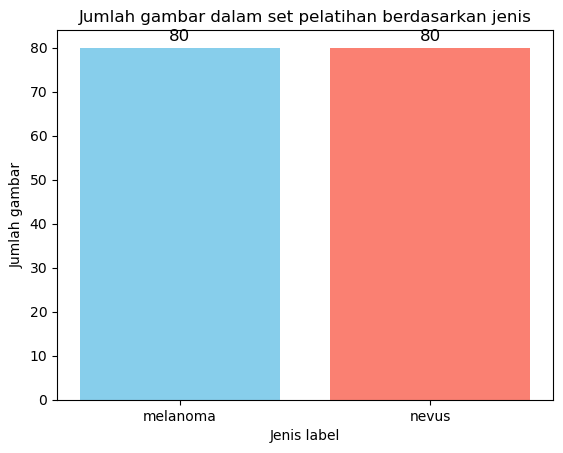

In [40]:
import matplotlib.pyplot as plt
import numpy as np

# Giả sử y_train là mảng nhãn dạng 1 chiều
labels, counts = np.unique(y_train, return_counts=True)

label_names = ['melanoma', 'nevus']

plt.bar(label_names, counts, color=['skyblue', 'salmon'])

# Hiển thị số lượng lên trên từng cột
for i, count in enumerate(counts):
    plt.text(i, count + max(counts)*0.01, str(count), ha='center', va='bottom', fontsize=12)

plt.xlabel('Jenis label')
plt.ylabel('Jumlah gambar')
plt.title('Jumlah gambar dalam set pelatihan berdasarkan jenis')
plt.show()

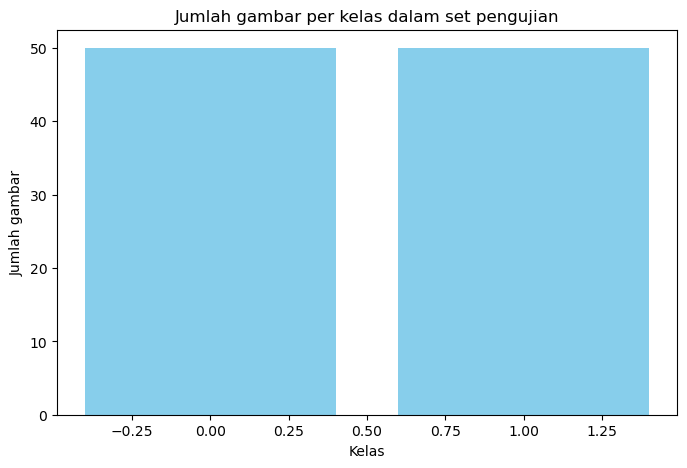

In [41]:
import numpy as np
import matplotlib.pyplot as plt

# Giả sử y_test là mảng nhãn
# Đếm số lượng mỗi lớp
labels, counts = np.unique(y_test, return_counts=True)

# Vẽ biểu đồ cột
plt.figure(figsize=(8,5))
plt.bar(labels, counts, color='skyblue')
plt.xlabel('Kelas')
plt.ylabel('Jumlah gambar')
plt.title('Jumlah gambar per kelas dalam set pengujian')
plt.show()

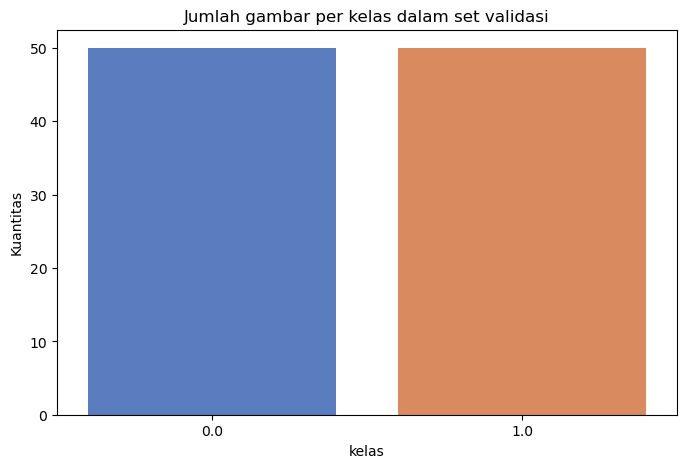

In [42]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


y_val_series = pd.Series(y_test)
counts = y_val_series.value_counts().reset_index()
counts.columns = ['kelas', 'Kuantitas']

plt.figure(figsize=(8,5))
sns.barplot(x='kelas', y='Kuantitas', data=counts, palette='muted')
plt.title('Jumlah gambar per kelas dalam set validasi')
plt.show()